In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
drive.mount('/content/drive')

# Carregando base
path = '/content/drive/My Drive/Pós FIAP/Datathon/base_consolidada.csv'
df = pd.read_csv(path)

Mounted at /content/drive


In [ ]:
df.head()

,RA,ano_nascimento,idade_atual,genero,faixa_etaria,ano_ingresso,status,instituicao_ensino,fase_2022,fase_2023,...,ingles_2023,ingles_2024,ingles_media,adequacao_nivel_2022,adequacao_nivel_2023,adequacao_nivel_2024,adequacao_nivel_media,fase_ideal_2022,fase_ideal_2023,fase_ideal_2024
0,RA-1,2003,22,Feminino,18+ anos,2021,Veterano,Escola Pública | Privada *Parcerias com Bolsa ...,7.0,8.0,...,NaN,NaN,6.0,5.0,10.0,10.0,8.333333,Fase 8 (Universitários),Fase 8 (Universitários),Fase 8 (Universitários)
1,RA-2,2005,20,Feminino,18+ anos,2021,Veterano,Rede Decisão | Privada *Parcerias com Bolsa 100%,7.0,8.0,...,NaN,NaN,9.7,10.0,10.0,10.0,10.000000,Fase 7 (3º EM),Fase 8 (Universitários),Fase 8 (Universitários)
2,RA-3,2005,20,Feminino,18+ anos,2016,Veterano,Rede Decisão,7.0,NaN,...,NaN,NaN,6.9,10.0,NaN,NaN,10.000000,Fase 7 (3º EM),NaN,NaN
3,RA-4,2005,20,Menino,18+ anos,2017,Veterano,Rede Decisão,7.0,NaN,...,NaN,NaN,8.7,10.0,NaN,NaN,10.000000,Fase 7 (3º EM),NaN,NaN
4,RA-5,2005,20,Feminino,18+ anos,2016,Veterano,Rede Decisão | Privada *Parcerias com Bolsa 100%,7.0,8.0,...,NaN,NaN,5.7,10.0,10.0,NaN,10.000000,Fase 7 (3º EM),Fase 8 (Universitários),NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1661 entries, 0 to 1660
Data columns (total 57 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   RA                         1661 non-null   object 
 1   ano_nascimento             1661 non-null   int64  
 2   idade_atual                1661 non-null   int64  
 3   genero                     1661 non-null   object 
 4   faixa_etaria               1661 non-null   object 
 5   ano_ingresso               1661 non-null   int64  
 6   status                     1661 non-null   object 
 7   instituicao_ensino         1660 non-null   object 
 8   fase_2022                  860 non-null    float64
 9   fase_2023                  783 non-null    float64
 10  fase_2024                  960 non-null    float64
 11  pedra_2022                 860 non-null    object 
 12  pedra_2023                 931 non-null    object 
 13  pedra_2024                 1092 non-null   objec

In [ ]:
df.isnull().sum()

,0
RA,0
ano_nascimento,0
idade_atual,0
genero,0
faixa_etaria,0
ano_ingresso,0
status,0
instituicao_ensino,1
fase_2022,801
fase_2023,878


In [ ]:
# 1. Limpeza Inicial: Removeção de colunas que estão 100% vazias
colunas_vazias = ['classificacao_geral_2023', 'classificacao_geral_2024']
df.drop(columns=colunas_vazias, errors='ignore', inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1661 entries, 0 to 1660
Data columns (total 55 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   RA                         1661 non-null   object 
 1   ano_nascimento             1661 non-null   int64  
 2   idade_atual                1661 non-null   int64  
 3   genero                     1661 non-null   object 
 4   faixa_etaria               1661 non-null   object 
 5   ano_ingresso               1661 non-null   int64  
 6   status                     1661 non-null   object 
 7   instituicao_ensino         1660 non-null   object 
 8   fase_2022                  860 non-null    float64
 9   fase_2023                  783 non-null    float64
 10  fase_2024                  960 non-null    float64
 11  pedra_2022                 860 non-null    object 
 12  pedra_2023                 931 non-null    object 
 13  pedra_2024                 1092 non-null   objec

#Tendências

In [ ]:
# Criação de Deltas (Evolução)
# Quanto o aluno evoluiu em Matemática e Português de 2022 para 2024
df['delta_matematica'] = df['matematica_2024'] - df['matematica_2022']
df['delta_portugues'] = df['portugues_2024'] - df['portugues_2022']

In [ ]:
# Engenharia de Variáveis Categóricas (Mapping das Pedras)
# Transformar as pedras em números para o modelo entender a hierarquia
mapa_pedras = {'Quartzo': 1, 'Ágata': 2, 'Ametista': 3, 'Topázio': 4}
df['pedra_2022_num'] = df['pedra_2022'].map(mapa_pedras)
df['pedra_2024_num'] = df['pedra_2024'].map(mapa_pedras)

# Criando feature de "Subida de Nível"
df['evolucao_pedra'] = df['pedra_2024_num'] - df['pedra_2022_num']

In [ ]:
# "Tempo de Instituição"
df['anos_na_instituicao'] = 2024 - df['ano_ingresso']

In [ ]:
# Tratamento de Outliers (Exemplo: Idades impossíveis)
# Se houver alguém com idade negativa ou acima de 100 por erro de digitação
df = df[(df['idade_atual'] > 0) & (df['idade_atual'] < 100)]

In [ ]:
# One-Hot Encoding para Gênero
df = pd.get_dummies(df, columns=['genero'], prefix='gen')

In [ ]:
# Criando a Flag: 1 se o dado era nulo, 0 se o dado era original
df['flag_falta_ingles'] = df['ingles_media'].isnull().astype(int)

# Agora, podemos preencher o valor nulo com 0 ou com a média
df['ingles_media'] = df['ingles_media'].fillna(0)

In [ ]:
# Lista de colunas para processar
colunas_com_nulos = ['psicossocial_media', 'aprendizagem_media', 'matematica_media']

for col in colunas_com_nulos:
    # 1. Cria a flag de aviso
    df[f'flag_missing_{col}'] = df[col].isnull().astype(int)

    # 2. Imputação pela Mediana (mais robusta a valores extremos que a média)
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)

In [ ]:
#Tratando as pedras
# 1. Substituir os nulos por 'Nao_Avaliado'
colunas_pedras = ['pedra_2022', 'pedra_2023', 'pedra_2024']

for col in colunas_pedras:
    df[col] = df[col].fillna('Nao_Avaliado')

# 2. Criar o mapeamento numérico (dando o valor 0 para quem não tem pedra)
mapa_pedras_hierarquia = {
    'Nao_Avaliado': 0,
    'Quartzo': 1,
    'Ágata': 2,
    'Ametista': 3,
    'Topázio': 4
}

# 3. Aplicar o mapeamento
for col in colunas_pedras:
    df[f'{col}_num'] = df[col].map(mapa_pedras_hierarquia)

In [ ]:
def tratar_com_flag(dataframe, coluna):
    # Cria a flag: 1 se for nulo, 0 se existir
    dataframe[f'flag_nulo_{coluna}'] = dataframe[coluna].isnull().astype(int)

    # Preenche o nulo com 0 (ou a média)
    # Como a flag já avisa que é nulo, o 0 não vai 'puxar' a média do modelo pra baixo injustamente
    dataframe[coluna] = dataframe[coluna].fillna(0)

    return dataframe

# Exemplo de aplicação nas colunas mais críticas
colunas_criticas = ['ingles_media', 'fase_2022', 'fase_2023', 'fase_2024']

for c in colunas_criticas:
    df = tratar_com_flag(df, c)

In [ ]:
df.head()

,RA,ano_nascimento,idade_atual,faixa_etaria,ano_ingresso,status,instituicao_ensino,fase_2022,fase_2023,fase_2024,...,gen_Menino,flag_falta_ingles,flag_missing_psicossocial_media,flag_missing_aprendizagem_media,flag_missing_matematica_media,pedra_2023_num,flag_nulo_ingles_media,flag_nulo_fase_2022,flag_nulo_fase_2023,flag_nulo_fase_2024
0,RA-1,2003,22,18+ anos,2021,Veterano,Escola Pública | Privada *Parcerias com Bolsa ...,7.0,8.0,8.0,...,False,0,0,0,0,0.0,0,0,0,0
1,RA-2,2005,20,18+ anos,2021,Veterano,Rede Decisão | Privada *Parcerias com Bolsa 100%,7.0,8.0,8.0,...,False,0,0,0,0,0.0,0,0,0,0
2,RA-3,2005,20,18+ anos,2016,Veterano,Rede Decisão,7.0,0.0,0.0,...,False,0,0,0,0,0.0,0,0,1,1
3,RA-4,2005,20,18+ anos,2017,Veterano,Rede Decisão,7.0,0.0,0.0,...,True,0,0,0,0,0.0,0,0,1,1
4,RA-5,2005,20,18+ anos,2016,Veterano,Rede Decisão | Privada *Parcerias com Bolsa 100%,7.0,8.0,0.0,...,False,0,0,0,0,0.0,0,0,0,1


In [ ]:
# Adicionamos o 'r' antes de '(\d+)' para corrigir o SyntaxWarning
df['fase_ideal_2024_num'] = df['fase_ideal_2024'].astype(str).str.extract(r'(\d+)').astype(float).fillna(0)
df['fase_2024_num'] = df['fase_2024'].astype(str).str.extract(r'(\d+)').astype(float).fillna(0)

# Recalculando o risco
df['aluno_em_risco'] = (
    (df['inde_2024'] < 5) |
    (df['engajamento_2024'] < 5) |
    (df['fase_2024_num'] < df['fase_ideal_2024_num'])
).astype(int)

print(f"Alunos identificados em risco: {df['aluno_em_risco'].sum()}")

Alunos identificados em risco: 710


#visualização gráfica

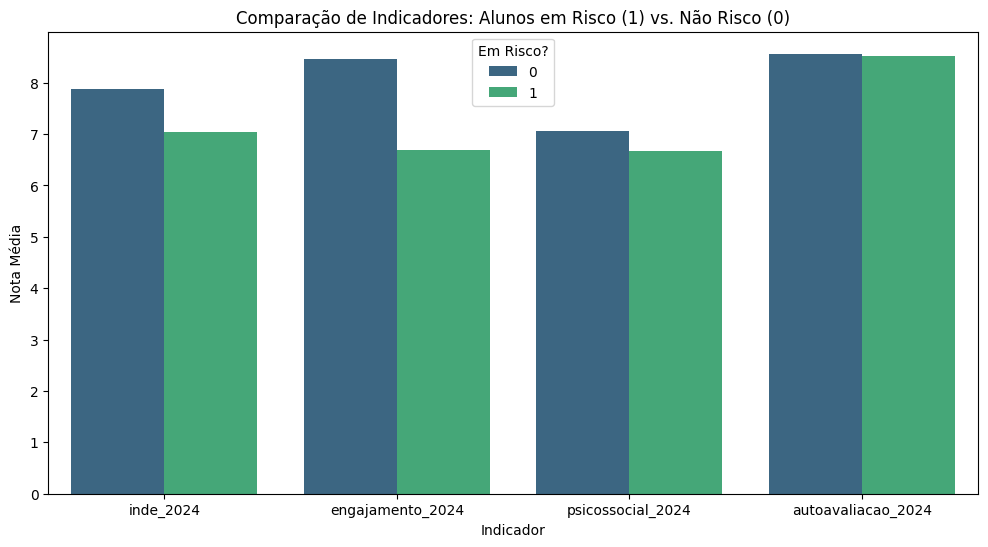

In [ ]:
# Criando um subset para comparação
indicadores = ['inde_2024', 'engajamento_2024', 'psicossocial_2024', 'autoavaliacao_2024']
comparacao = df.groupby('aluno_em_risco')[indicadores].mean().reset_index()

# Derretendo o dataframe para facilitar a plotagem no Seaborn
comparacao_melted = comparacao.melt(id_vars='aluno_em_risco', var_name='Indicador', value_name='Média')

plt.figure(figsize=(12, 6))
sns.barplot(data=comparacao_melted, x='Indicador', y='Média', hue='aluno_em_risco', palette='viridis')

plt.title('Comparação de Indicadores: Alunos em Risco (1) vs. Não Risco (0)')
plt.ylabel('Nota Média')
plt.legend(title='Em Risco?')
plt.show()

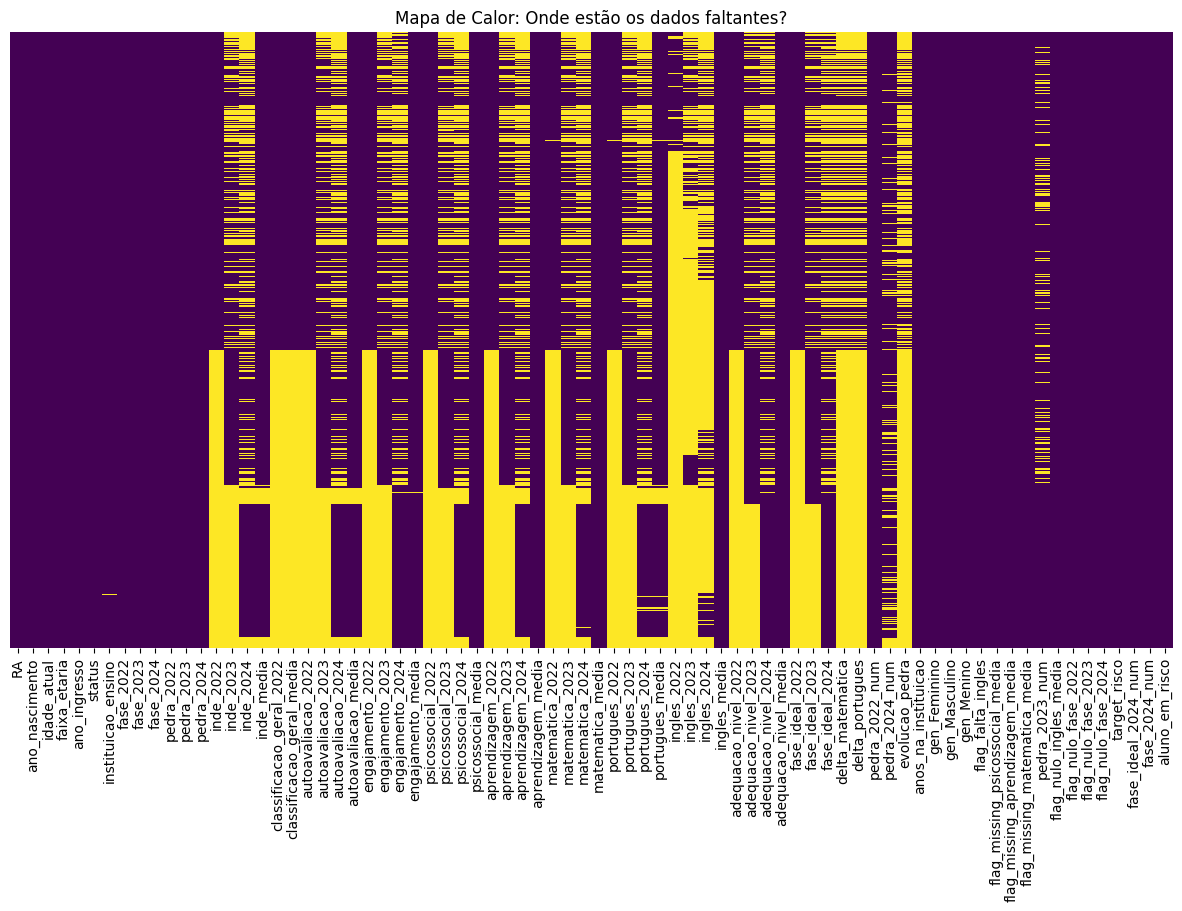

In [ ]:
# Configura o tamanho da imagem
plt.figure(figsize=(15, 8))

# Cria o heatmap de valores nulos
# sns.heatmap mostra True (1) para nulo e False (0) para preenchido
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title('Mapa de Calor: Onde estão os dados faltantes?')
plt.show()

In [ ]:
# Lista a porcentagem de nulos em cada coluna, do maior para o menor
nulos_pct = (df.isnull().sum() / len(df)) * 100
print(nulos_pct.sort_values(ascending=False))

ingles_2022            82.962071
ingles_2023            79.891632
evolucao_pedra         79.530403
delta_matematica       73.269115
delta_portugues        73.208910
                         ...    
flag_nulo_fase_2024     0.000000
target_risco            0.000000
fase_ideal_2024_num     0.000000
fase_2024_num           0.000000
aluno_em_risco          0.000000
Length: 76, dtype: float64


#Treino

In [ ]:
# Lista de features focada em indicadores que variam (evitando o vício)
features_ajustadas = [
    'matematica_media', 'portugues_media',
    'psicossocial_media', 'autoavaliacao_media',
    'engajamento_media', 'anos_na_instituicao',
    'pedra_2022_num', 'pedra_2024_num',
    'delta_matematica', 'delta_portugues'
]

# Garantir que não existam nulos nas colunas escolhidas antes do split
X = df[features_ajustadas].copy()
for col in features_ajustadas:
    X[col] = X[col].fillna(X[col].median())

y = df['aluno_em_risco']

In [ ]:
# Split dos dados (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Definição do Modelo
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=5,
    max_depth=10, # Adicionei profundidade máxima para evitar overfitting
    random_state=42
)

In [ ]:
# Treino APENAS no conjunto de treino
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=5, n_estimators=200,
                       random_state=42)

In [ ]:
#Avaliação no conjunto de teste (Dados que o modelo nunca viu)
y_pred = modelo_rf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       191
           1       0.81      0.83      0.82       142

    accuracy                           0.84       333
   macro avg       0.84      0.84      0.84       333
weighted avg       0.84      0.84      0.84       333



In [ ]:
# Gerar probabilidades para todos os alunos da base original
probabilidades = modelo_rf.predict_proba(X)[:, 1]

df_entrega_final = pd.DataFrame({
    'RA': df['RA'],
    'Probabilidade_Risco_%': (probabilidades * 100).round(2),
    'Status_Real_2024': df['aluno_em_risco'].map({1: 'Em Risco', 0: 'Estável'}),
    'INDE_2024': df['inde_2024'].fillna(0),
    'Sugestao_Prioridade': pd.cut(probabilidades, bins=[0, 0.3, 0.7, 1], labels=['Baixa', 'Média', 'Alta'])
})

# Ordenar pelos alunos que o modelo acha que têm mais chance de risco
df_entrega_final = df_entrega_final.sort_values(by='Probabilidade_Risco_%', ascending=False)
print(df_entrega_final.head(10))

           RA  Probabilidade_Risco_% Status_Real_2024  INDE_2024  \
1639  RA-1640                  99.42         Em Risco        0.0   
1638  RA-1639                  99.42         Em Risco        0.0   
1660  RA-1661                  99.42         Em Risco        0.0   
1637  RA-1638                  99.42         Em Risco        0.0   
1636  RA-1637                  99.42         Em Risco        0.0   
1659  RA-1660                  99.42         Em Risco        0.0   
1658  RA-1659                  99.42         Em Risco        0.0   
1649  RA-1650                  99.42         Em Risco        0.0   
1648  RA-1649                  99.42         Em Risco        0.0   
1647  RA-1648                  99.42         Em Risco        0.0   

     Sugestao_Prioridade  
1639                Alta  
1638                Alta  
1660                Alta  
1637                Alta  
1636                Alta  
1659                Alta  
1658                Alta  
1649                Alta  
1648    

In [ ]:
import joblib

# 1. Definir a lista final e oficial de colunas (na ordem que o modelo vai ler)
features_finais = [
    'matematica_media', 'portugues_media',
    'psicossocial_media', 'autoavaliacao_media',
    'engajamento_media',
    'anos_na_instituicao', 'pedra_2022_num', 'pedra_2024_num',
    'delta_matematica', 'delta_portugues'
]

# 2. Garantir que o X do treino use apenas essas colunas
X_final = df[features_finais].fillna(df[features_finais].median())
y_final = df['aluno_em_risco']

# 3. Treinar o modelo final
modelo_final = RandomForestClassifier(n_estimators=200, min_samples_leaf=5, random_state=42)
modelo_final.fit(X_final, y_final)

# 4. Exportar
joblib.dump(modelo_final, 'modelo_risco_final.pkl')
joblib.dump(features_finais, 'colunas_modelo.pkl')

print("✅ Sucesso! Envie os arquivos 'modelo_risco_final.pkl' e 'colunas_modelo.pkl' para o desenvolvedor do Streamlit.")

✅ Sucesso! Envie os arquivos 'modelo_risco_final.pkl' e 'colunas_modelo.pkl' para o desenvolvedor do Streamlit.
